# KMeans

Lloyd's algorithm
Elkan algorithm

Инициализация центроид:
**random**, **kmeans++**

**elbow method**:
Поиск оптимального значения $k$

In [58]:
class _KMeans:
    def __init__(self, k=3, init='random', max_iter=300):
        self.k = k
        self.init = init
        self.max_iter = max_iter
        self.min_distance_ = 1e-4
        self.centroids = None
        self.labels_ = None
        
    def kmeans_plus_plus(self, X):
        n_samples, _ = X.shape
        centroids = [X[np.random.choice(n_samples)]]
        
        for _ in range(1, self.k):
            distances = np.min([
                np.sum((X - c)**2, axis=1) for c in centroids
            ], axis=0)

            probabilities = distances / distances.sum()
            chosen_idx = np.random.choice(n_samples, p=probabilities)
            centroids.append(X[chosen_idx])
            
    def fit(self, X):
        if self.init == 'random':
            centroid_ids = np.random.choice(X.shape[0], self.k, replace=False)
            self.cluster_centers = X[centroid_ids]
        elif self.init == 'k-means++':
            self.cluster_centers = self.kmeans_plus_plus(X)
    
        for i in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers, axis=2)
            labels = np.argmin(distances, axis=1)
            
            new_centroids = np.array([
                X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else self.cluster_centers[i]
                for i in range(self.k)
            ])
            
            shift = np.linalg.norm(self.cluster_centers - new_centroids)
            self.cluster_centers = new_centroids
            if shift < self.min_distance_:
                break
                
        self.labels_ = labels
        
    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers, axis=2)
        return np.argmin(distances, axis=1)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


------

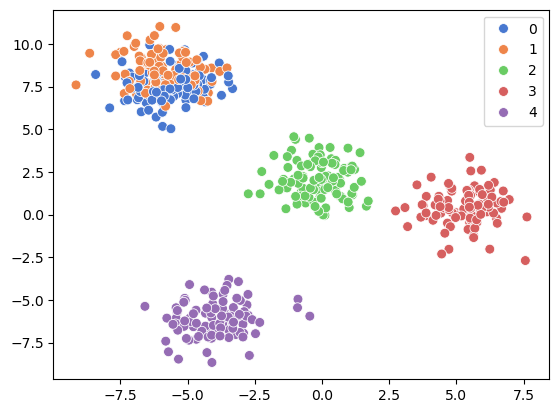

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=500, random_state=5, centers=5)

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=50, palette='muted');

In [2]:
from sklearn.cluster import KMeans
sk_kmeans = KMeans(algorithm='elkan')
y_sk_kmeans = sk_kmeans.fit_predict(X)

In [3]:
centers = sk_kmeans.cluster_centers_

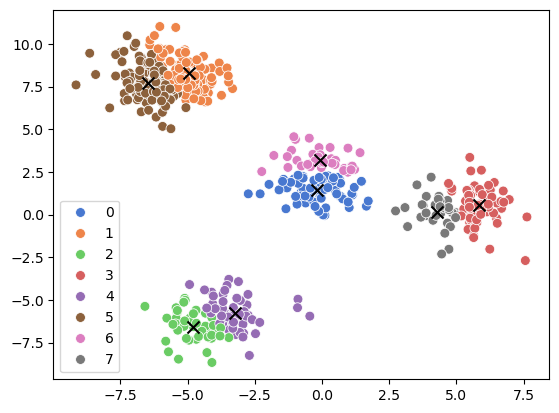

In [4]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_sk_kmeans, s=50, palette='muted')
plt.scatter(centers[:, 0], centers[:, 1], marker='x', c='black', s=75);

# Elbow-Method

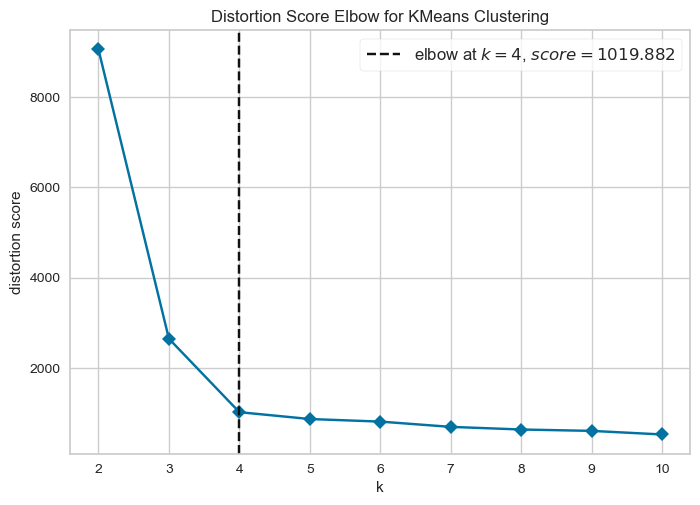

In [86]:
from yellowbrick.cluster import KElbowVisualizer
elbow = KElbowVisualizer(sk_kmeans, k=10, timings=False)
elbow.fit(X)
elbow.show();

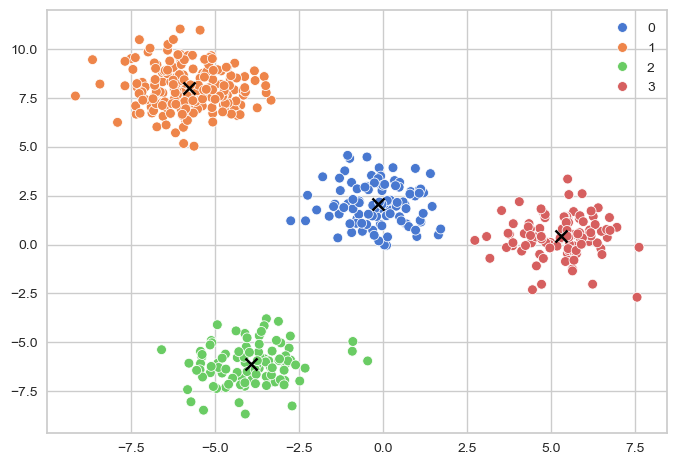

In [105]:
best_k = elbow.elbow_value_
sk_kmeans = KMeans(n_clusters = best_k)
y_best = sk_kmeans.fit_predict(X)
k_centers = sk_kmeans.cluster_centers_
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_best, s=50, palette='muted')
plt.scatter(k_centers[:, 0], k_centers[:, 1], marker='x', c='black', s=75);